# Parameter Exploration

Marius Pille (Berlin Institute of Health at Charité University
Medicine)  
Leon Martin (Berlin Institute of Health at Charité University
Medicine)  
Leon Stefanovski (Charité University Medicine Berlin)

In [1]:
import bsplot
import matplotlib.pyplot as plt

from tvbo import Dynamics, SimulationExperiment
from tvbo.datamodel.schema import Exploration, ExplorationAxis

bsplot.style.use("tvbo")

# Sweeping parameters declaratively

In Chapter 1 we changed parameters by re-instantiating the `Dynamics`.
That is fine for one or two values, but it scales badly. TVBO has a
first-class metadata object for this: `Exploration`.

An `Exploration` lives on `experiment.explorations` and is dispatched by
the backend when you call `.run()`.

## A one-axis sweep

We take the `Generic2dOscillator` and sweep its bifurcation parameter
`a` across five values.

In [2]:
model = Dynamics.from_db("Generic2dOscillator")

exp = SimulationExperiment(dynamics=model)
exp.integration.duration = 800       # ms
exp.integration.step_size = 0.01      # ms

exp.explorations["a_sweep"] = Exploration(
    name="a_sweep",
    space=ExplorationAxis(parameter="a", explored_values=[-2.0, -1.0, 0.0, 1.0, 2.0]),
)

result = exp.run("tvboptim")


STEP 1: Running simulation...
  Simulation period: 800.0 ms, dt: 0.01 ms
  Transient period: 0.0 ms
  Simulation complete.

STEP 2: Running explorations...
  > a_sweep
  Explorations complete.

Experiment complete.

The result keeps the same shape conventions as a single simulation, with
one extra axis for the swept parameter:

In [3]:
sweep = result.explorations["a_sweep"]
print("results shape:", sweep.results.shape, "  axis:", sweep.axes[0].name)

results shape: (5, 80000, 2, 1)   axis: a

`Exploration.plot()` overlays the trajectories. Increasing `a` walks the
system through a Hopf bifurcation: from a stable focus to a sustained
limit cycle.

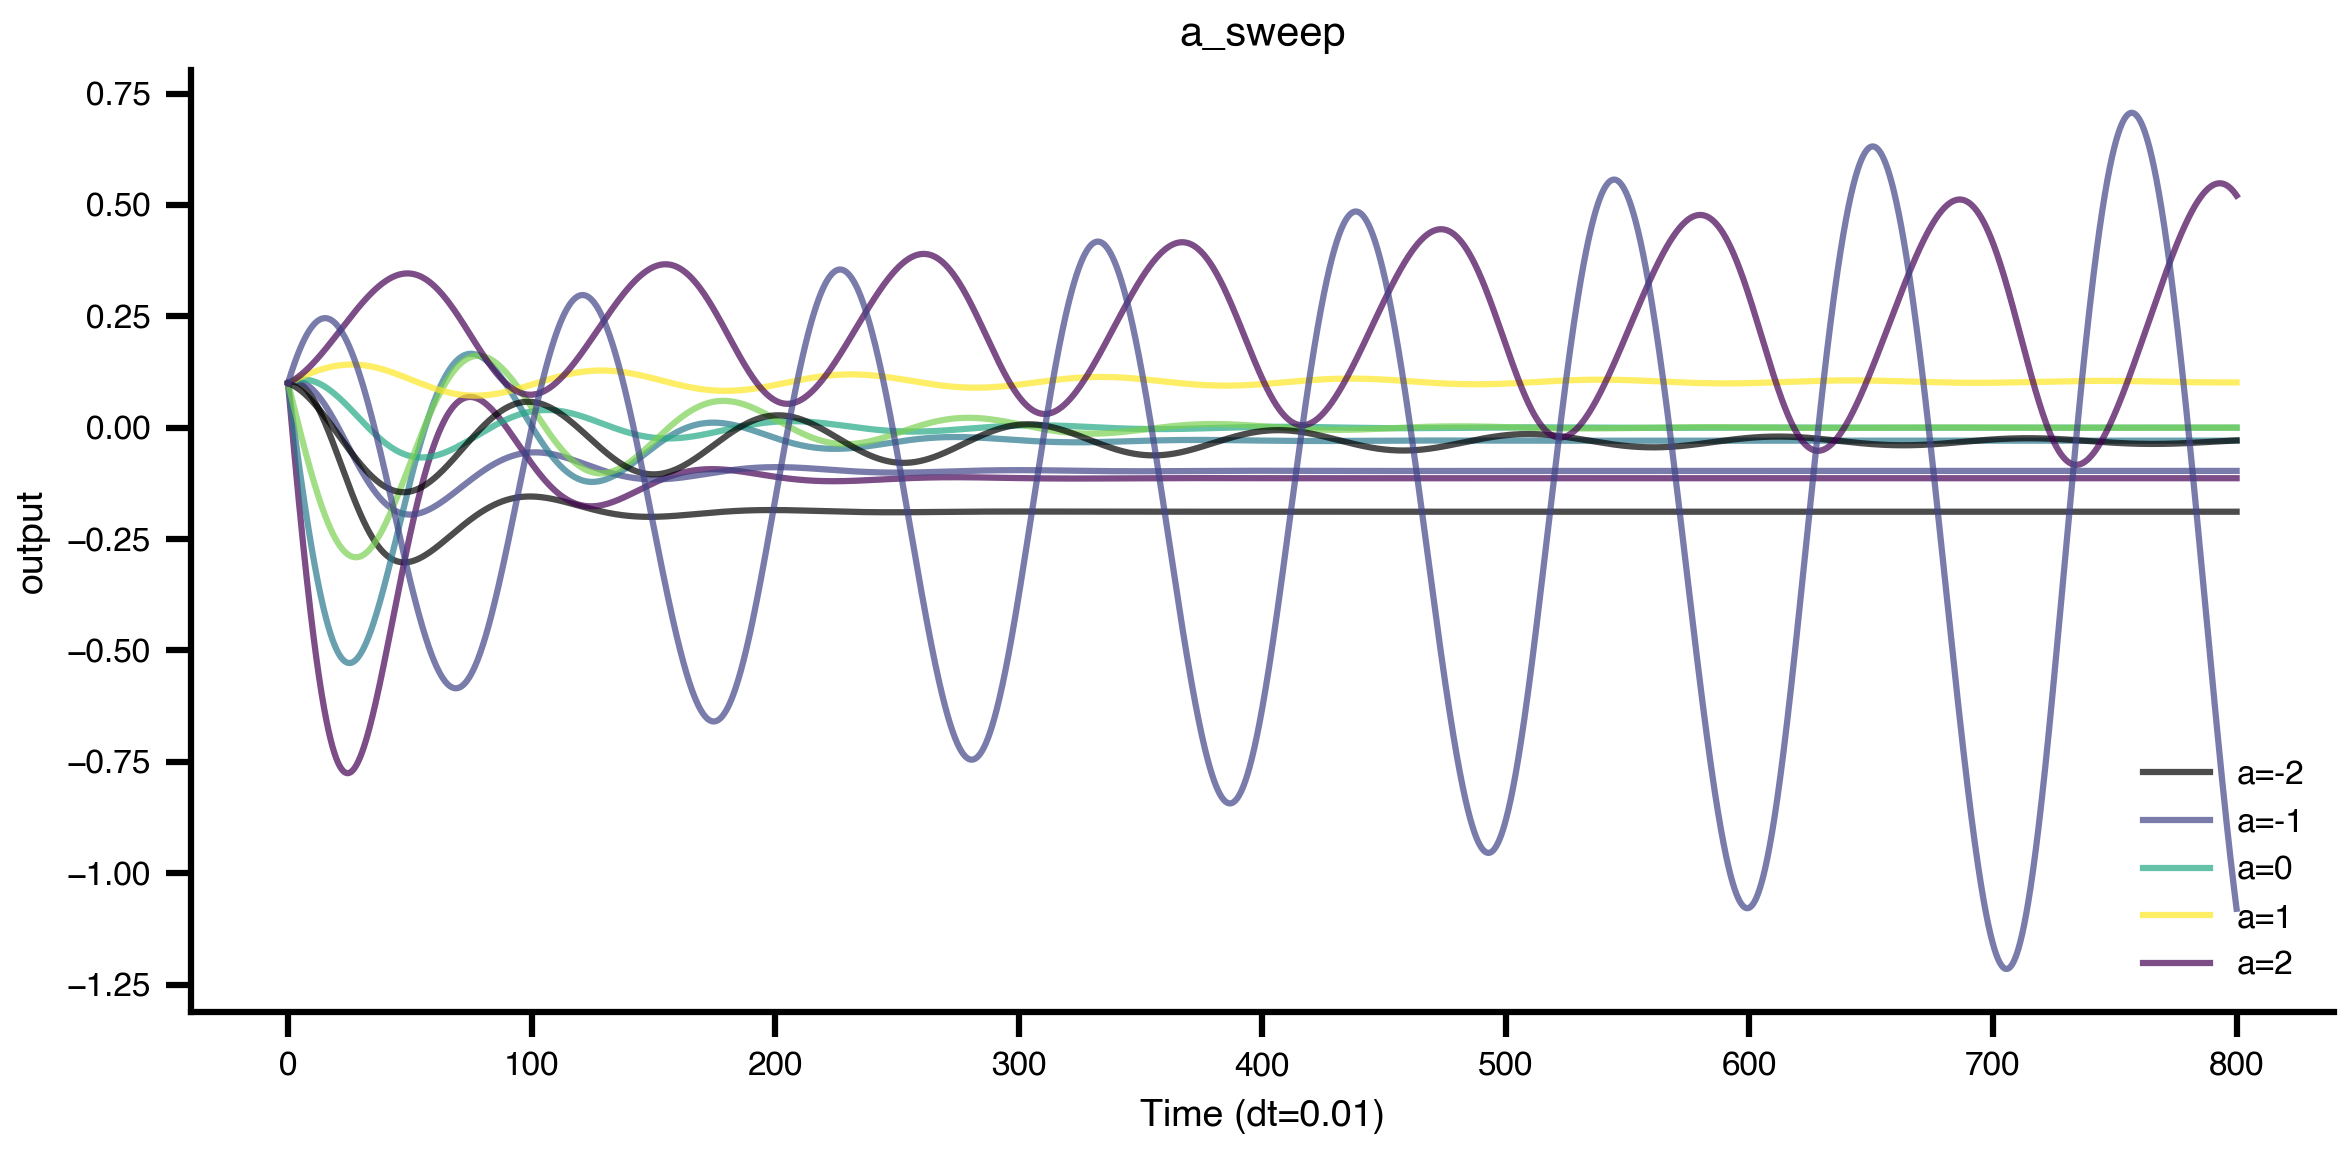

In [4]:
sweep.plot(overlay=True)

## Observations

In [5]:
from tvbo import Observation

exp.observations['mean_V'] = Observation(
    name='mean_V',
    source='V',  # the state variable to observe
    aggregation='mean',  # aggregate over space (node dimension)
)

res = exp.run()


STEP 1: Running simulation...
  Simulation period: 800.0 ms, dt: 0.01 ms
  Transient period: 0.0 ms
  Simulation complete.

STEP 2: Running explorations...
  > a_sweep
  Explorations complete.

Experiment complete.

In [6]:
from tvbo import Observation
from tvbo.datamodel.schema import FunctionCall, Callable, Argument
import numpy
exp.observations['mean_V'] = Observation(
    name='V_mean',
    source='V',
    pipeline=[
        FunctionCall(
            name='spatial_mean',
            callable=Callable(
                name='mean',
                module='np',
            ),
            input='V',
        ),
    ],
)
exp.run().observations['mean_V'].data


STEP 1: Running simulation...
  Simulation period: 800.0 ms, dt: 0.01 ms
  Transient period: 0.0 ms
  Simulation complete.

STEP 2: Running explorations...
  > a_sweep
  Explorations complete.

Experiment complete.

Array(-0.18526074, dtype=float64)

## Trial-based exploration

The same object also drives Monte-Carlo style replication via
`n_trials`. Each trial uses different initial conditions and (if noise
is configured) different noise realisations.


STEP 1: Running simulation...
  Simulation period: 800.0 ms, dt: 0.01 ms
  Transient period: 0.0 ms
  Simulation complete.

STEP 2: Running explorations...
  > a_sweep
  > trials
  Explorations complete.

Experiment complete.

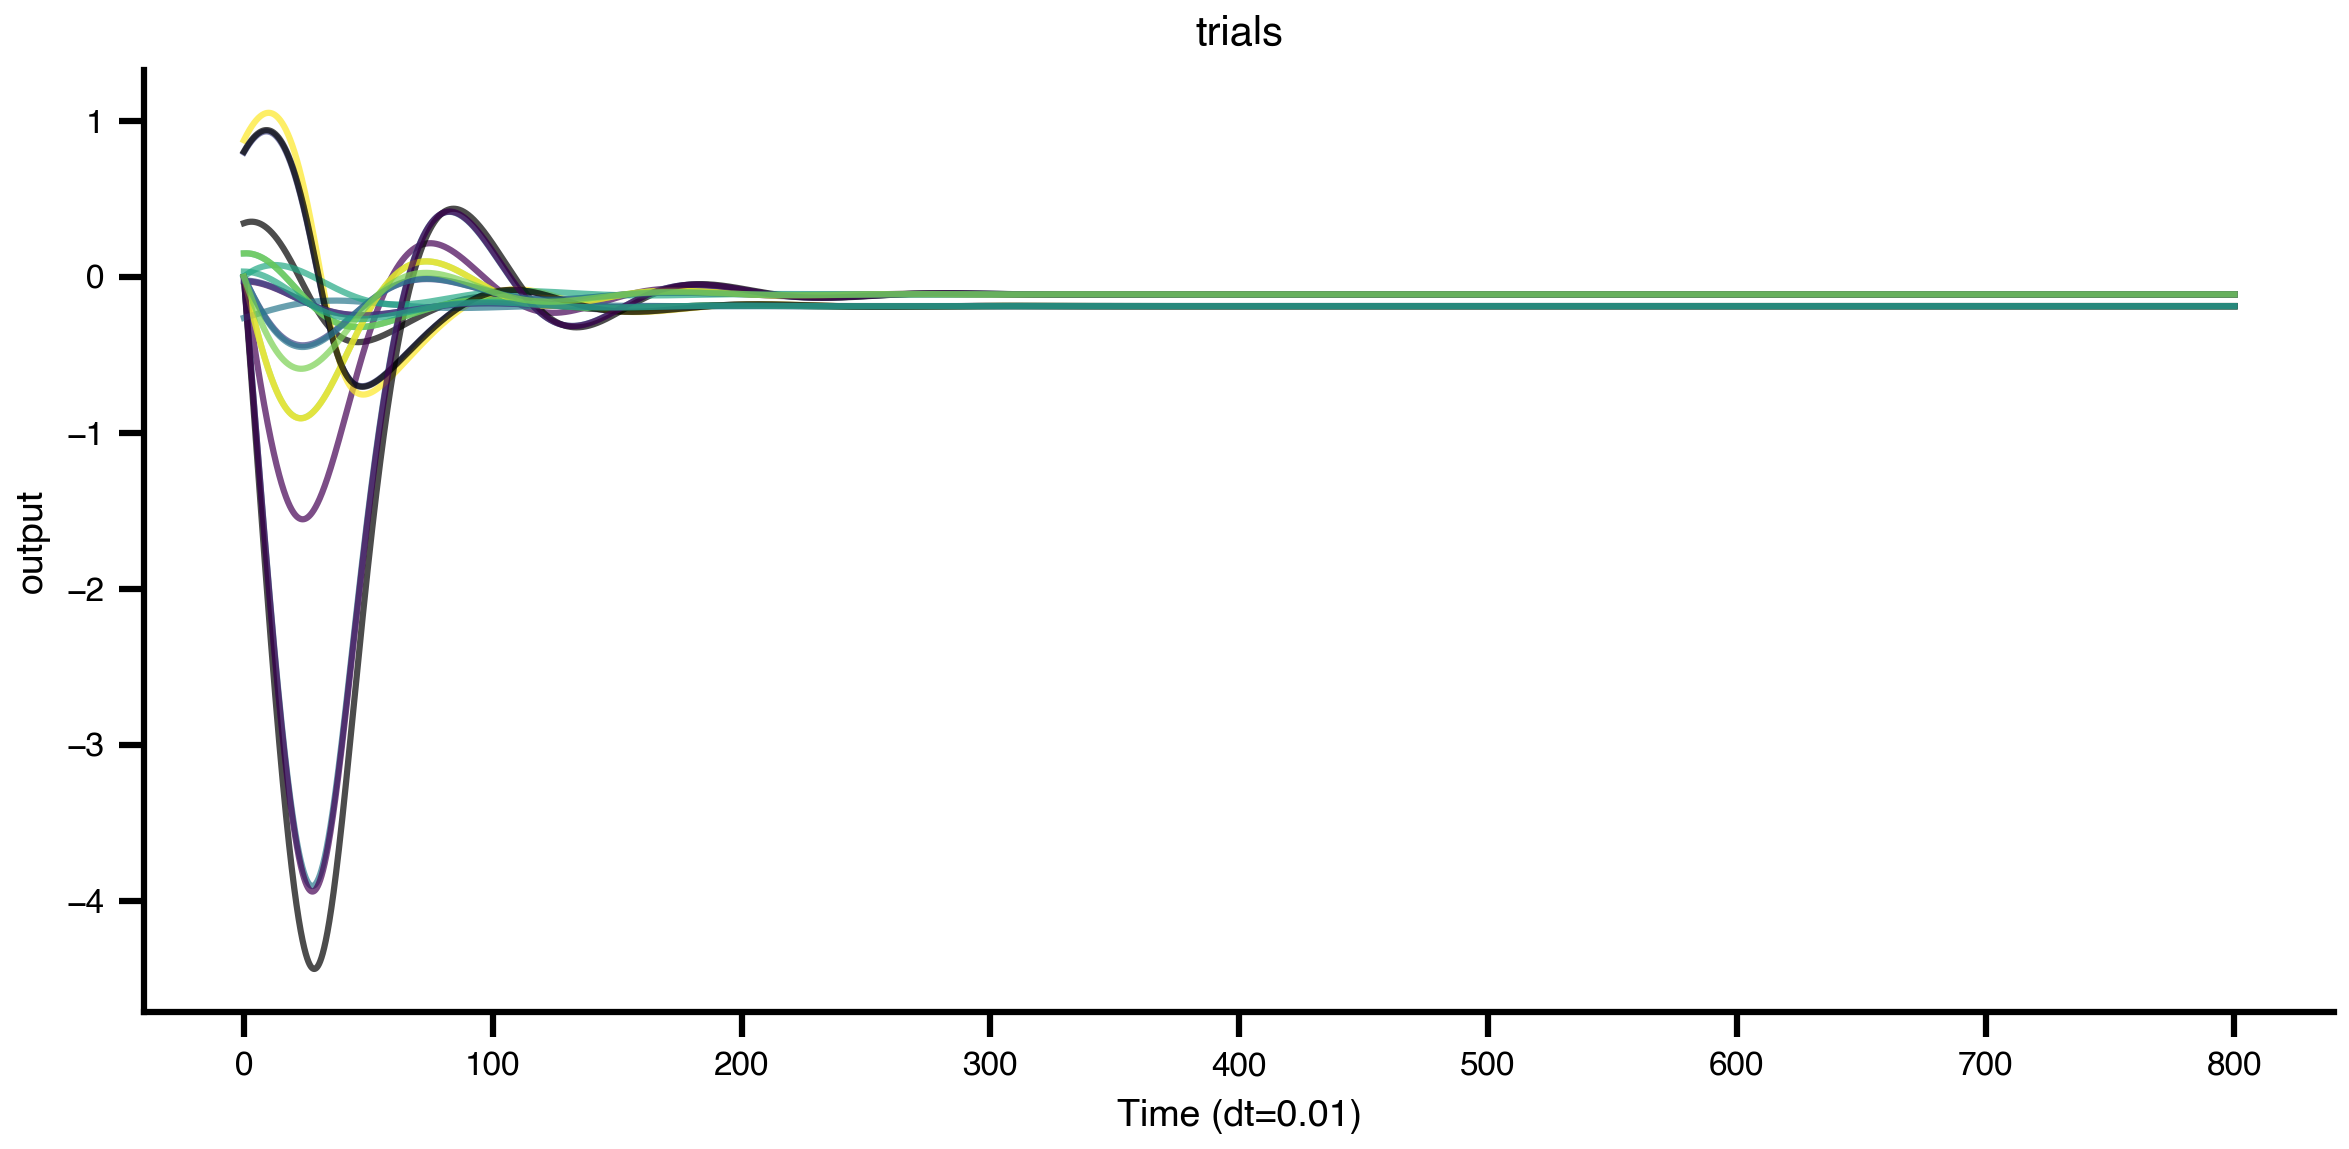

In [7]:
from tvbo.datamodel.schema import Distribution, Range
# exp.explorations.clear()

exp.dynamics.state_variables['V'].distribution = Distribution(domain=Range(lo=-1, hi=1))
exp.dynamics.state_variables['W'].initial_value = 0

exp.explorations["trials"] = Exploration(name="trials", n_trials=10)

result = exp.run("tvboptim")

result.explorations["trials"].plot(overlay=True)

## Recap

-   `exp.explorations[name] = Exploration(...)` declares a sweep — never
    assign a plain dict.
-   `ExplorationAxis(parameter=..., explored_values=[...])` defines the
    axis.
-   `n_trials=N` runs `N` randomised replicates.
-   The backend (`tvboptim`) vectorises the sweep automatically; nothing
    else changes.

The next chapter takes the same `Dynamics` object and replaces
brute-force sweeping with **continuation**, which tracks equilibria and
limit cycles directly.